# Strategy 01: Baseline Without Balancing

Establishes reference metrics by training on a naturally imbalanced dataset with no balancing strategy. Demonstrates how class imbalance degrades Macro-F1 and inflates TPRGap.

## Local Setup

Hardware-specific configurations

In [1]:
import sys
import os
import socket

if socket.gethostname() == "proc8":
	os.environ["CUDA_VISIBLE_DEVICES"] = "3"

## Pipeline Setup

In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

sys.path.append(os.path.abspath(".."))

from src.data_utils import get_tokenized_dataset
from src.eval_utils import evaluate_model
from src.plot_utils import plot_metrics, results_to_dataframe
from src.train_utils import train_model
from src.paths import MODELS_DIR

/home/phmgc/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
MODEL_NAME  = "roberta-base"
TRAIN_RATIO = 0.8   # for datasets without native train/test splits
SEED        = 42

# All datasets
DATASETS = {
    # Ribeiro et al. [A–J]
    "ribeiro": [
    #"sentistrength_twitter", "vader_amazon", "english_dailabor", "debate",
    #"sentistrength_youtube", "vader_twitter", "tweet_semevaltest",
    "sentistrength_myspace", #"sentistrength_digg", "sentistrength_bbc",
	],
    # McAuley Lab [K–M]
    "mcauley": [
        "luxury_beauty", "cds_reviews", "digital_music",
    ],
    # Control (Stanford NLP Group)
    "stanfordnlp": [
		"imdb",
	],
}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## Load/Tokenize Datasets

In [4]:
tokenized = {}  # {"author/dataset": (train_tok, eval_tok)}

for author, names in DATASETS.items():
    for name in names:
        dataset_id = f"{author}/{name}"
        try:
            train_tok = get_tokenized_dataset(author, name, tokenizer, split="train", strategy="baseline", train_ratio=TRAIN_RATIO, seed=SEED)
            eval_tok  = get_tokenized_dataset(author, name, tokenizer, split="test",  strategy="baseline", train_ratio=TRAIN_RATIO, seed=SEED).shuffle(seed=SEED)
            tokenized[dataset_id] = (train_tok, eval_tok)
            print(f"  {dataset_id:30s}  train={len(train_tok):,}  test={len(eval_tok):,}")
        except RuntimeError as e:
            print(f"Skipping '{dataset_id}': {e}")

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 13472.07it/s]


Tokenizado baixado do Hub (PHMGC/roberta-bias-reduction-datasets/tokenized/ribeiro__sentistrength_myspace_train_baseline)


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 19831.22it/s]


Tokenizado baixado do Hub (PHMGC/roberta-bias-reduction-datasets/tokenized/ribeiro__sentistrength_myspace_test_baseline)
  ribeiro/sentistrength_myspace   train=667  test=167


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 24.15it/s]


...


  mcauley/digital_music           train=1,220,236  test=305,060


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 12252.11it/s]


Tokenizado baixado do Hub (PHMGC/roberta-bias-reduction-datasets/tokenized/stanfordnlp__imdb_train_baseline)


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 14665.40it/s]

Tokenizado baixado do Hub (PHMGC/roberta-bias-reduction-datasets/tokenized/stanfordnlp__imdb_test_baseline)
  stanfordnlp/imdb                train=25,000  test=25,000


## Training

In [5]:
MODELS_BASELINE_DIR = MODELS_DIR / "baseline"

for dataset_id, (train_tok, _) in tokenized.items():
    model_dir = MODELS_BASELINE_DIR / dataset_id
    if model_dir.exists():
        print(f"  {dataset_id}: model already cached, skipping training")
        continue
    print(f"  Training: {dataset_id}")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    train_model(model=model, train_dataset=train_tok, tokenizer=tokenizer,
                output_dir=str(model_dir), epochs=3)

  Training: ribeiro/sentistrength_myspace


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7843.54it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo já treinado na Nuvem (Hugging Face) em: baseline/ribeiro/sentistrength_myspace
  Training: mcauley/luxury_beauty


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7056.60it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo já treinado na Nuvem (Hugging Face) em: baseline/mcauley/luxury_beauty
  Training: mcauley/cds_reviews


...

Modelo já treinado na Nuvem (Hugging Face) em: baseline/mcauley/cds_reviews
  Training: mcauley/digital_music


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7097.39it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo já treinado na Nuvem (Hugging Face) em: baseline/mcauley/digital_music
  Training: stanfordnlp/imdb


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7261.24it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo já treinado na Nuvem (Hugging Face) em: baseline/stanfordnlp/imdb


## Evaluation

In [6]:
results = {}
repo_id = "PHMGC/roberta-bias-reduction"

for name, (_, eval_tok) in tokenized.items():
    model_dir = MODELS_BASELINE_DIR / name
    has_weights = (model_dir / "model.safetensors").exists() or (model_dir / "pytorch_model.bin").exists()
    if has_weights:
        model = AutoModelForSequenceClassification.from_pretrained(str(model_dir))
    else:
        print(f"  {name}: Baixando pesos do Hugging Face Hub")
        model = AutoModelForSequenceClassification.from_pretrained(
            repo_id,
            subfolder=f"baseline/{name}"
        )

    results[name] = evaluate_model(model, eval_tok)
    m = results[name]
    print(f"  {name:30s}  Macro-F1={m['macro_f1']:.4f}  TPRGap={m['tpr_gap']:.4f}  Acc={m['accuracy']:.4f}")

  ribeiro/sentistrength_myspace: Baixando pesos do Hugging Face Hub


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  6.68it/s]


  ribeiro/sentistrength_myspace   Macro-F1=0.8264  TPRGap=0.1871  Acc=0.9102
  mcauley/luxury_beauty: Baixando pesos do Hugging Face Hub


Evaluating: 100%|██████████| 1664/1664 [01:46<00:00, 15.58it/s]


  mcauley/luxury_beauty           Macro-F1=0.9555  TPRGap=0.0755  Acc=0.9777
  mcauley/cds_reviews: Baixando pesos do Hugging Face Hub


...

  mcauley/cds_reviews             Macro-F1=0.4807  TPRGap=1.0000  Acc=0.9256
  mcauley/digital_music: Baixando pesos do Hugging Face Hub


Evaluating: 100%|██████████| 4767/4767 [05:11<00:00, 15.33it/s]


  mcauley/digital_music           Macro-F1=0.4889  TPRGap=1.0000  Acc=0.9566
  stanfordnlp/imdb: Baixando pesos do Hugging Face Hub


Evaluating: 100%|██████████| 391/391 [00:28<00:00, 13.78it/s]


  stanfordnlp/imdb                Macro-F1=0.8975  TPRGap=0.0662  Acc=0.8976


## Results

In [7]:
import importlib, src.data_utils, src.plot_utils
importlib.reload(src.data_utils)
importlib.reload(src.plot_utils)
from src.plot_utils import plot_metrics, results_to_dataframe

In [9]:
results_to_dataframe(results).round(4)

,accuracy,macro_f1,tpr_class_0,tpr_class_1,tpr_gap,imbalance_ratio
dataset,,,,,,
mcauley/cds_reviews,0.9256,0.4807,0.0000,1.0000,1.0000,12.3464
mcauley/digital_music,0.9566,0.4889,0.0000,1.0000,1.0000,21.8872
ribeiro/sentistrength_myspace,0.9102,0.8264,0.7500,0.9371,0.1871,5.3182
stanfordnlp/imdb,0.8976,0.8975,0.9307,0.8645,0.0662,1.0000
mcauley/luxury_beauty,0.9777,0.9555,0.9134,0.9889,0.0755,5.6549


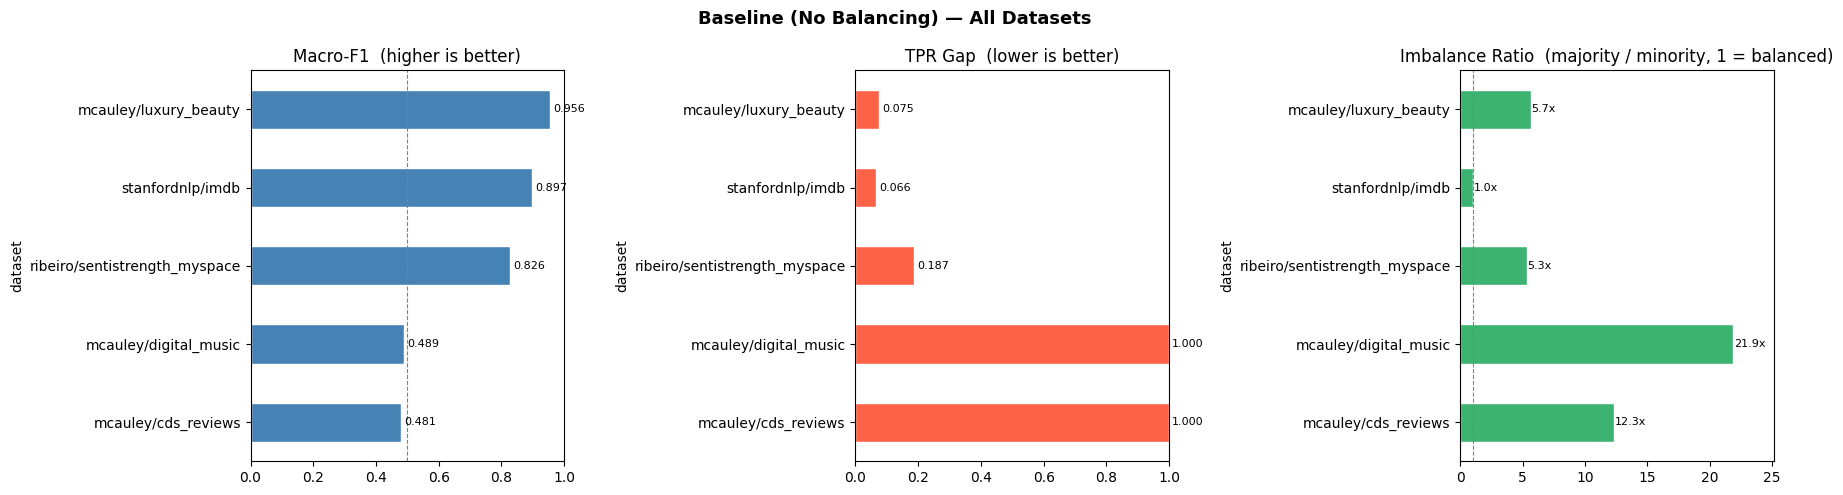

In [10]:
plot_metrics(results, title="Baseline (No Balancing) — All Datasets")

## Conclusion

When class imbalance is severe, **TPRGap increases sharply** even when **accuracy remains high**, indicating strong bias toward the majority class.  
When imbalance is moderate or low, the model can learns both classes reasonably well, resulting in a low TPRGap and better-balanced performance (higher Macro-F1).